In [2]:
import pandas as pd
import seaborn as sns
from IPython.display import display

In [3]:
sns.set_theme(font_scale=2, palette='colorblind')

In [4]:
pokemon_url = 'https://raw.githubusercontent.com/lgreski/pokemonData/refs/heads/master/Pokemon.csv'
pokemon_df = pd.read_csv(pokemon_url,index_col=0)

In [5]:
pokemon_df['Type2']

ID
1         Poison
2         Poison
3         Poison
4               
5               
          ...   
1006    Fighting
1007      Dragon
1008      Dragon
1009      Dragon
1010     Psychic
Name: Type2, Length: 1194, dtype: object

In [6]:
pokemon_df.dtypes

Name          object
Form          object
Type1         object
Type2         object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
dtype: object

In [7]:
sns.set_palette('colorblind')

As you can see, Pokemon with only one type have a missing value for the 'Type 2' column. In order to clean this I want to replace the empty values with NaN.

I want to find the average total stats of pokemon that have two types: a valid type 1 and a valid type 2, based on the secondary type. Pokemon with one type wont be included in this. To fix the issue of an empty type2 still being counted as that Pokemon having a type2, I will change all the empty values to NaN.

In [10]:
pokemon_df = pd.read_csv(pokemon_url,na_values=' ',index_col=0)

In [11]:
pokemon_df.dropna(subset='Type2')

,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
ID,,,,,,,,,,,,
1,Bulbasaur,NaN,Grass,Poison,318,45,49,49,65,65,45,1
2,Ivysaur,NaN,Grass,Poison,405,60,62,63,80,80,60,1
3,Venusaur,NaN,Grass,Poison,525,80,82,83,100,100,80,1
6,Charizard,NaN,Fire,Flying,534,78,84,78,109,85,100,1
12,Butterfree,NaN,Bug,Flying,395,60,45,50,90,80,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1006,Iron Valiant,NaN,Fairy,Fighting,590,74,130,90,120,60,116,9
1007,Koraidon,NaN,Fighting,Dragon,670,100,135,115,85,100,135,9
1008,Miraidon,NaN,Electric,Dragon,670,100,85,100,135,115,135,9


In [12]:
pokemon_df_grouped = pokemon_df.groupby('Type2', as_index=False)['Total'].mean()

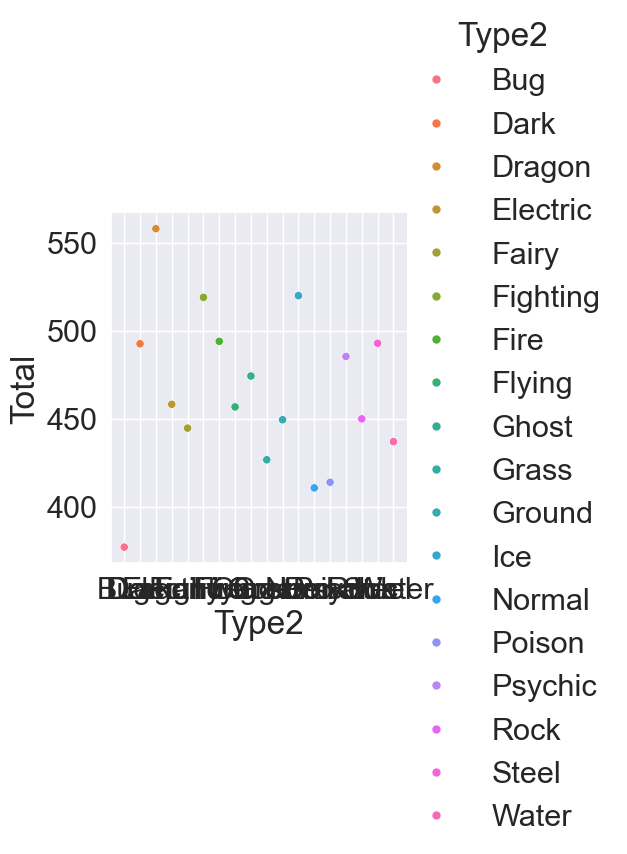

In [13]:
sns.relplot(data=pokemon_df_grouped, x='Type2', y='Total', hue='Type2')